In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

print("✅ All libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")

✅ All libraries imported successfully!
Pandas: 2.3.3
Numpy: 2.4.3


In [2]:
df = pd.read_csv('../Labels.csv')

In [3]:
print(df.head())

print(f"\nTotal numbers  of data: {len(df)}")
print(f"\nColumns Name: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN

Total numbers  of data: 747

Columns Name: ['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4']

Data Types:
Image Name        object
Patient            int64
Label             object
Quality Score    float64
Unnamed: 4       float64
dtype: object


In [4]:
df = df.drop(columns=['Unnamed: 4'])


In [5]:
print("Label Distribution:")
print(df['Label'].value_counts())
print(f"\nPercentage:")
print(df['Label'].value_counts(normalize=True).round(3) * 100)

Label Distribution:
Label
GON+    548
GON-    199
Name: count, dtype: int64

Percentage:
Label
GON+    73.4
GON-    26.6
Name: proportion, dtype: float64


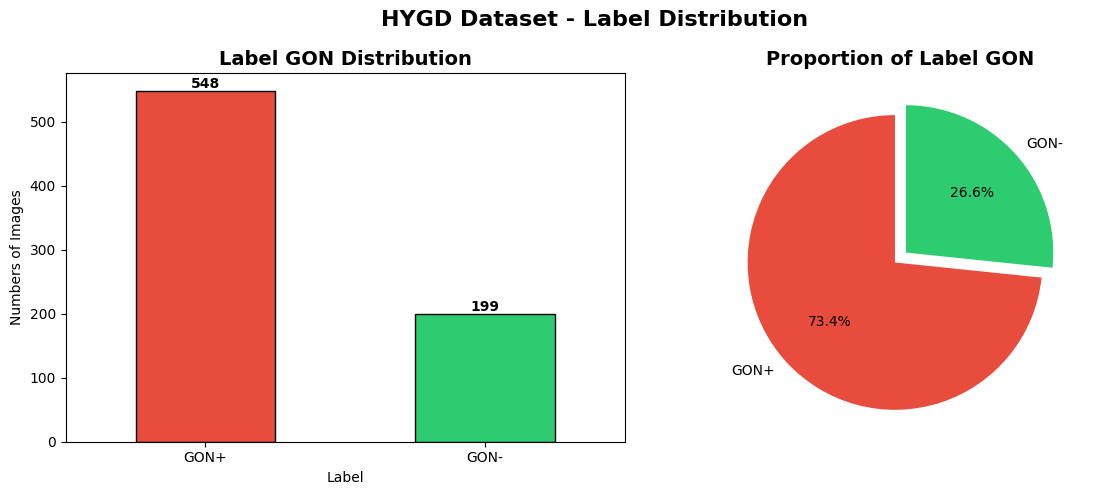

✅ Label distribution visualization completed!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Bar chart
colors = ['#e74c3c', '#2ecc71']
df['Label'].value_counts().plot(
    kind='bar', 
    ax=axes[0], 
    color=colors,
    edgecolor='black'
)
axes[0].set_title('Label GON Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Numbers of Images')
axes[0].tick_params(rotation=0)

for i, v in enumerate(df['Label'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Pie chart
df['Label'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title('Proportion of Label GON', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('HYGD Dataset - Label Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Label distribution visualization completed!")

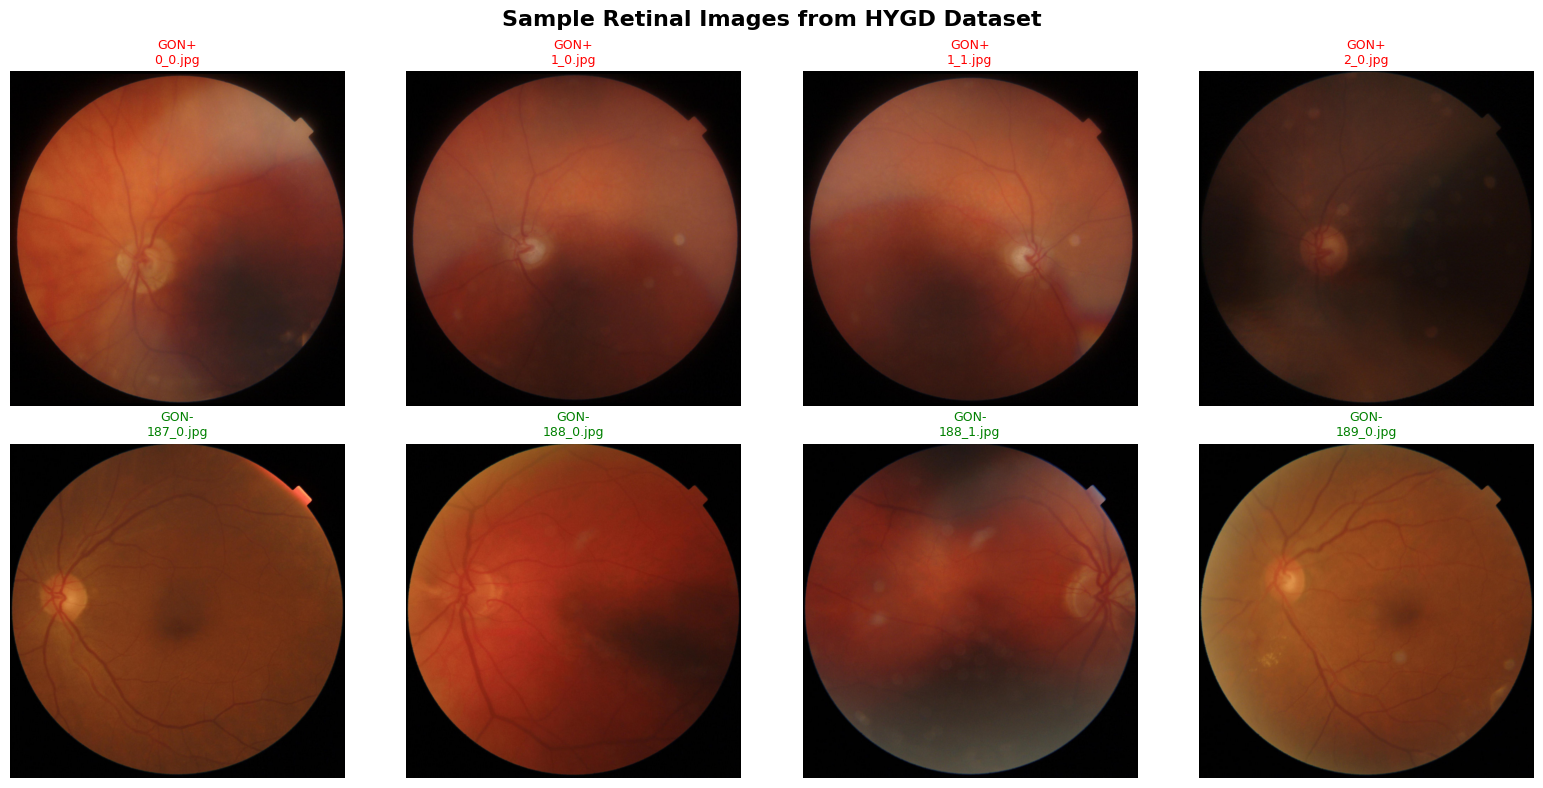

✅ Sample images displayed successfully!


In [7]:
import cv2
import matplotlib.pyplot as plt
import os

image_folder = '../Images'

gon_plus = df[df['Label'] == 'GON+']['Image Name'].values[:4]
gon_minus = df[df['Label'] == 'GON-']['Image Name'].values[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# GON+
for i, img_name in enumerate(gon_plus):
    img_path = os.path.join(image_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'GON+\n{img_name}', fontsize=9, color='red')
    axes[0, i].axis('off')

# GON-
for i, img_name in enumerate(gon_minus):
    img_path = os.path.join(image_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'GON-\n{img_name}', fontsize=9, color='green')
    axes[1, i].axis('off')

plt.suptitle('Sample Retinal Images from HYGD Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample images displayed successfully!")

Statistik Quality Score:
count    747.00
mean       5.90
std        1.01
min        2.04
25%        5.36
50%        6.18
75%        6.63
max        7.69
Name: Quality Score, dtype: float64


/tmp/ipykernel_15998/1648432483.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


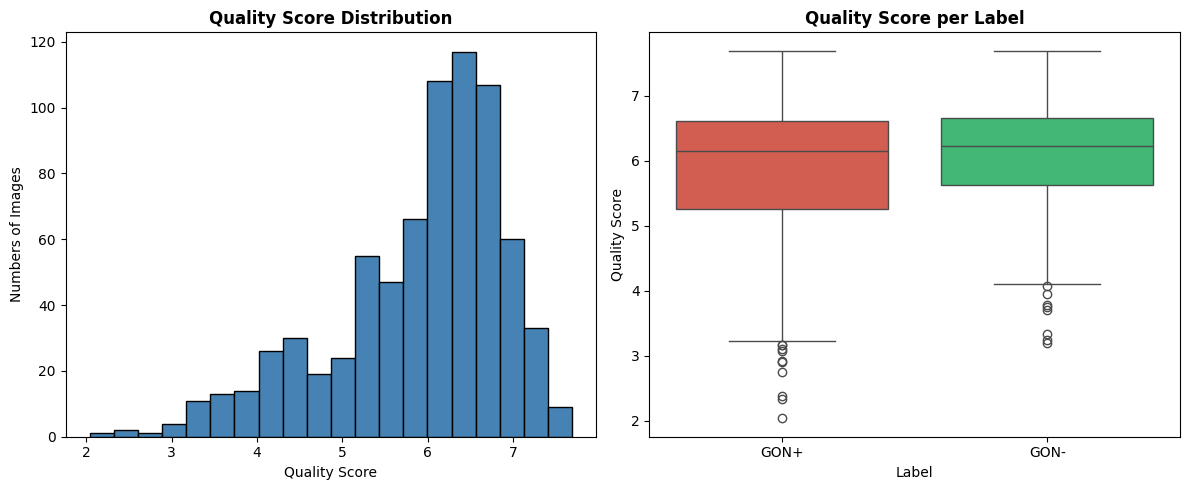

✅ Quality score analysis completed!


In [8]:
# Analisis Quality Score
print("Statistik Quality Score:")
print(df['Quality Score'].describe().round(2))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(df['Quality Score'], bins=20, 
             color='steelblue', edgecolor='black')
axes[0].set_title('Quality Score Distribution', fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Numbers of Images')

# Boxplot per label (pakai seaborn, lebih simpel)
import seaborn as sns
sns.boxplot(
    data=df, 
    x='Label', 
    y='Quality Score',
    palette={'GON+': '#e74c3c', 'GON-': '#2ecc71'},
    ax=axes[1]
)
axes[1].set_title('Quality Score per Label', fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Quality Score')

plt.tight_layout()
plt.savefig('../notebooks/quality_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Quality score analysis completed!")

✅ Grafik Quality Score Berhasil!

Yang Bisa Dibaca dari Grafik:
Histogram (kiri):

Mayoritas foto punya quality score 5-7
Distribusi mendekati normal (bell curve)
Ada beberapa foto dengan score rendah (2-3) → foto berkualitas buruk

Boxplot (kanan):

GON+ dan GON- punya quality score hampir sama (~6)
Ada beberapa outlier di bawah (score 2-3) di kedua label
Artinya kualitas foto tidak bias ke salah satu label ✅

In [9]:
# Check how many photos have low quality scores
low_quality = df[df['Quality Score'] < 4]
print(f"Photos with quality score < 4: {len(low_quality)}")
print(low_quality[['Image Name', 'Label', 'Quality Score']])

# Filter only photos with quality score >= 4
df_filtered = df[df['Quality Score'] >= 4].reset_index(drop=True)
print(f"\nData before filter: {len(df)}")
print(f"Data after filter: {len(df_filtered)}")
print(f"\nDistribution after filter:")
print(df_filtered['Label'].value_counts())

Photos with quality score < 4: 46
    Image Name Label  Quality Score
3      2_0.jpg  GON+           3.51
12     7_0.jpg  GON+           2.34
21    10_2.jpg  GON+           3.33
31    14_1.jpg  GON+           2.75
50    20_0.jpg  GON+           3.85
169   58_1.jpg  GON+           3.60
170   58_2.jpg  GON+           3.60
179   62_0.jpg  GON+           3.42
285   95_0.jpg  GON+           3.78
297   99_5.jpg  GON+           3.43
308  101_0.jpg  GON+           3.37
321  105_1.jpg  GON+           3.89
324  107_1.jpg  GON+           3.94
325  107_2.jpg  GON+           3.73
335  109_4.jpg  GON+           3.93
340  112_0.jpg  GON+           3.08
346  114_2.jpg  GON+           3.81
347  115_0.jpg  GON+           2.92
348  115_1.jpg  GON+           3.85
353  118_1.jpg  GON+           3.79
371  128_0.jpg  GON+           2.38
372  129_0.jpg  GON+           3.51
374  129_2.jpg  GON+           3.55
385  135_3.jpg  GON+           3.73
386  135_4.jpg  GON+           3.97
391  138_1.jpg  GON+          

In [10]:
# Verify image path is readable
image_folder = '../Images'

# Cek 5 first images
print("Checking image availability:")
for img_name in df_filtered['Image Name'].values[:5]:
    img_path = os.path.join(image_folder, img_name)
    exists = os.path.exists(img_path)
    print(f"{'✅' if exists else '❌'} {img_name} → {img_path}")

# Save df_filtered as a clean CSV file
df_filtered.to_csv('../notebooks/labels_filtered.csv', index=False)
print(f"\n✅ labels_filtered.csv saved successfully!")
print(f"Total ready data: {len(df_filtered)} images")

Checking image availability:
✅ 0_0.jpg → ../Images/0_0.jpg
✅ 1_0.jpg → ../Images/1_0.jpg
✅ 1_1.jpg → ../Images/1_1.jpg
✅ 2_1.jpg → ../Images/2_1.jpg
✅ 3_0.jpg → ../Images/3_0.jpg

✅ labels_filtered.csv saved successfully!
Total ready data: 701 images


In [11]:
# Analisis informasi pasien
print("Images Total:", len(df_filtered))
print("\nUnique Patients:", df_filtered['Patient'].nunique())
print("\nNumber of Images per Patient (First 5):")
print(df_filtered.groupby('Patient').size().head())

Images Total: 701

Unique Patients: 281

Number of Images per Patient (First 5):
Patient
0    1
1    2
2    1
3    2
4    1
dtype: int64


In [12]:
from PIL import Image
import os

image_folder = '../Images'

# Cek the sizes of the first 20 images
image_sizes = []
for img_name in df_filtered['Image Name'].head(20):
    img_path = os.path.join(image_folder, img_name)
    if os.path.exists(img_path):
        with Image.open(img_path) as img:
            image_sizes.append(img.size)

print("First 20 image sizes:")
print(image_sizes)

print("\nUnique sizes found:")
print(set(image_sizes))

First 20 image sizes:
[(1918, 1918), (1929, 1929), (1940, 1940), (1900, 1900), (1892, 1892), (1885, 1885), (1915, 1915), (1889, 1889), (1889, 1889), (1919, 1919), (1889, 1889), (1940, 1940), (1890, 1890), (1891, 1891), (1900, 1900), (1960, 1960), (1913, 1913), (1878, 1878), (1881, 1881), (1885, 1885)]

Unique sizes found:
{(1881, 1881), (1929, 1929), (1919, 1919), (1890, 1890), (1892, 1892), (1891, 1891), (1918, 1918), (1940, 1940), (1915, 1915), (1913, 1913), (1960, 1960), (1885, 1885), (1889, 1889), (1878, 1878), (1900, 1900)}


In [13]:
# Change GON+/GON- to numeric values 1/0
label_map = {'GON+': 1, 'GON-': 0}
df_filtered['label_numeric'] = df_filtered['Label'].map(label_map)

print("Data after encoding:")
print(df_filtered.head())

print("\nDistribution of numeric labels:")
print(df_filtered['label_numeric'].value_counts())

# Save the updated CSV with numeric labels
df_filtered.to_csv('../labels_filtered.csv', index=False)
print("\n✅ labels_filtered.csv updated with numeric labels!")

Data after encoding:
  Image Name  Patient Label  Quality Score  label_numeric
0    0_0.jpg        0  GON+           6.18              1
1    1_0.jpg        1  GON+           5.31              1
2    1_1.jpg        1  GON+           4.37              1
3    2_1.jpg        2  GON+           4.24              1
4    3_0.jpg        3  GON+           5.95              1

Distribution of numeric labels:
label_numeric
1    509
0    192
Name: count, dtype: int64

✅ labels_filtered.csv updated with numeric labels!


In [14]:
print(df.tail(10))

    Image Name  Patient Label  Quality Score
737  283_0.jpg      283  GON-           5.79
738  283_1.jpg      283  GON-           6.74
739  284_0.jpg      284  GON-           6.53
740  284_1.jpg      284  GON-           7.17
741  285_0.jpg      285  GON-           5.68
742  286_0.jpg      286  GON-           6.69
743  286_1.jpg      286  GON-           6.01
744  287_0.jpg      287  GON-           4.51
745  287_1.jpg      287  GON-           5.31
746  288_0.jpg      288  GON-           4.87


Sum Images with Quality Score > 7:

In [15]:
high_quality = df[df['Quality Score'] > 7]
print(f"Images with Quality Score > 7: {len(high_quality)}")

Images with Quality Score > 7: 61


Average quality score:

In [ ]:
print(f"Average Quality Score: {df['Quality Score'].mean().round(2)}")

Average Quality Score: 5.9


Total Images per label per patient:

In [ ]:
print(df.groupby(['Patient', 'Label']).size())

Patient  Label
0        GON+     1
1        GON+     2
2        GON+     2
3        GON+     2
4        GON+     1
                 ..
284      GON-     2
285      GON-     1
286      GON-     2
287      GON-     2
288      GON-     1
Length: 288, dtype: int64
